# Taller 8 · DFT II: Aplicaciones de la DFT

**Asignatura:** Teoría de la Información y Procesado de Señal  
**Grado en Ciencia e Ingeniería de Datos (GCED) — Universidad de A Coruña**  
**Duración:** 2 horas  
**Modalidad:** Jupyter Notebook con asistencia de IA

---

## Objetivos de aprendizaje

Al finalizar este taller serás capaz de:

1. Calcular la **respuesta en frecuencia** $|H(f)|$ de un sistema.
2. Justificar el comportamiento de filtros vistos en el Taller 6.
4. Estimar la **PSD** y relacionarla con la autocorrelación.
5. Realizar **filtrado en frecuencia** (multiplicar espectros).
6. Analizar señales no estacionarias con **STFT/espectrograma**.

---

## 🎯 Reto central del taller

> **En el Taller 6 observaste qué pasa. Ahora entenderás *por qué*.**
>
> Usamos **exactamente las mismas señales y sistemas** del Taller 6, pero ahora los analizamos en el dominio de la frecuencia. Lo que allí describías como "suave" o "rápido" aquí lo justificarás con $|H(f)|$, espectros y PSD.

---

## Señales y sistemas (los mismos del Taller 6)

| Señal | Definición | Descripción |
|-------|------------|-------------|
| $x_1[n]$ | $\sin(2\pi f_1 n) + \sin(2\pi f_2 n)$ | Suma de dos tonos ($f_1=0.05$, $f_2=0.30$) |
| $x_2[n]$ | $\mathcal{N}(0,1)$ | Ruido blanco gaussiano |
| $x_3[n]$ | $x_2[n] * h_{\text{media}}[n]$ | Ruido suavizado (filtrado) |

| Sistema | Ecuación | Tipo |
|---------|----------|------|
| Media móvil | $h_1[n] = \frac{1}{M}\mathbf{1}_{[0,M-1]}$ | Paso bajo |
| Diferenciador | $y[n] = x[n] - x[n-1]$ | Paso alto |

---

## Metodología de trabajo con IA

| Puedes pedir a la IA | NO debes pedir a la IA |
|---------------------|------------------------|
| Código para PSD, STFT, freqz | Que interprete los resultados |
| Sintaxis de scipy.signal | Que complete las explicaciones |
| Depuración de errores | Que responda las preguntas de control |

> *La IA te ayuda a escribir código, pero no a entender señales. Eso es tu trabajo.*

---

## Identificación del estudiante

Completa los siguientes campos con tu información personal:

- **Apellidos:** Martínez Martínez

- **Nombre:** Jimena

- **Email UDC:** jimena.martinez@udc.es

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import IPython.display as ipd       # Integración de contenido multimedia en Jupyter Notebooks
import librosa  # Análisis y procesado de audio. 

np.random.seed(42)  # ¡Misma semilla que T6 para reproducibilidad!
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 11

print("✓ Entorno listo")

✓ Entorno listo


---

## Parte 0: Generación de las señales base (idénticas a T6)

In [19]:
# === PARÁMETROS COMUNES (idénticos al Taller 6) ===
N = 512          # número de muestras
n = np.arange(N)

# Frecuencias normalizadas (ciclos por muestra)
f1 = 0.05   # frecuencia baja
f2 = 0.30   # frecuencia alta

# Orden del filtro de media móvil
M = 15

# === SEÑAL x1: suma de dos tonos ===
x1 = np.sin(2 * np.pi * f1 * n) + np.sin(2 * np.pi * f2 * n)

# === SEÑAL x2: ruido blanco ===
x2 = np.random.randn(N)

# === FILTRO h1: media móvil ===
h_media = np.ones(M) / M

# === FILTRO h2: diferenciador ===
h_diff = np.array([1, -1])

# === SEÑAL x3: ruido suavizado ===
x3 = np.convolve(x2, h_media, mode='same')

print(f"✓ Señales generadas (idénticas al Taller 6):")
print(f"  x1: suma de tonos (f1={f1}, f2={f2})")
print(f"  x2: ruido blanco")
print(f"  x3: ruido suavizado (M={M})")

✓ Señales generadas (idénticas al Taller 6):
  x1: suma de tonos (f1=0.05, f2=0.3)
  x2: ruido blanco
  x3: ruido suavizado (M=15)


---

## Parte 1: Respuesta en frecuencia de los sistemas

### Contexto

La **respuesta en frecuencia** $H(e^{j\omega})$ describe cómo un sistema afecta a cada frecuencia:

$$Y(e^{j\omega}) = H(e^{j\omega}) \cdot X(e^{j\omega})$$

- **|H|**: Ganancia por frecuencia (qué pasa, qué se atenúa)
- **∠H**: Fase por frecuencia (retardos)

---

### Bloque 1 · $|H(f)|$ del filtro de media móvil

#### 📝 Hipótesis previa

Antes de ejecutar nada, deja escrita tu predicción:

1. ¿En cuál de las dos frecuencias, $f_1$ o $f_2$, esperas mayor ganancia? Espero mayor ganancia en f1 (frecuencia baja).
2. Si el filtro "suaviza" en tiempo, ¿qué tipo de frecuencias debería atenuar? Debería atenuar las frecuencias altas, ya que corresponden a cambios rápidos en la señal.

#### 🔗 Conexión con Taller 6

> En el T6 viste que al filtrar $x_1$ con la media móvil, sobrevivía el seno de **frecuencia baja** ($f_1=0.05$) y se atenuaba el de **frecuencia alta** ($f_2=0.30$).
>
> Ahora veremos $|H(f)|$ para **justificar por qué**.

---

In [20]:
# === IMPLEMENTACIÓN ===
# TODO: Calcula la respuesta en frecuencia del filtro de media móvil (h_media) con N muestras, H_media
H_media = np.fft.fft(h_media, N)

# TODO: Calcula el vector de frecuencias normalizada, f_norm
f_norm = np.arange(N) / N

# TODO: Calcula la posición de los bins de f1 y f2 en f_norm, idx_f1 y idx_f2
idx_f1 = np.argmin(np.abs(f_norm - f1))
idx_f2 = np.argmin(np.abs(f_norm - f2))

# TODO: Calcula la ganancia en f1 y f2 (valor absoluto de la respuesta en frecuencia en los bins f1 y f2), ganancia_f1 y ganancia_f2
ganancia_f1 = np.abs(H_media[idx_f1])
ganancia_f2 = np.abs(H_media[idx_f2])

In [21]:
# === VALIDACIÓN ===
idx_f1_empirica = np.argmin(np.abs(f_norm - f1))
idx_f2_empirica = np.argmin(np.abs(f_norm - f2))

assert H_media is not None, "Calcula la respuesta en frecuencia"
assert len(f_norm) == N, "El vector de frecuencias normalizadas debe tener N elementos"
assert idx_f1 == idx_f1_empirica, "El índice de f1 debe ser el mismo"
assert idx_f2 == idx_f2_empirica, "El índice de f2 debe ser el mismo"
assert ganancia_f1 > ganancia_f2, "El primer tono debe recuperarse con más ganancia que el segundo"

print(f"✓ Ganancia del filtro media móvil:")
print(f"  En f1={f1} -> |H[{idx_f1}]| = {ganancia_f1:.4f} ({20*np.log10(ganancia_f1):.1f} dB)")
print(f"  En f2={f2} -> |H[{idx_f2}]| = {ganancia_f2:.4f} ({20*np.log10(ganancia_f2+1e-10):.1f} dB)")

✓ Ganancia del filtro media móvil:
  En f1=0.05 -> |H[26]| = 0.2856 (-10.9 dB)
  En f2=0.3 -> |H[154]| = 0.0822 (-21.7 dB)


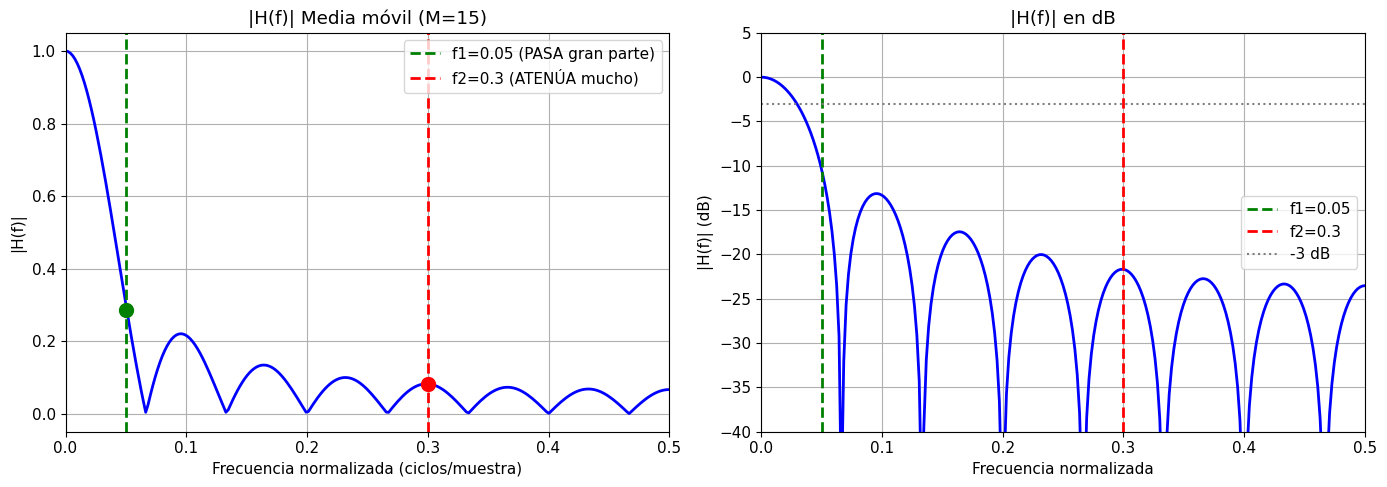

In [22]:
# === VISUALIZACIÓN ===
H_media_dB = 20 * np.log10(np.abs(H_media) + 1e-10)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Magnitud
axes[0].plot(f_norm, np.abs(H_media), 'b-', linewidth=2)
axes[0].axvline(f1, color='green', linestyle='--', linewidth=2, label=f'f1={f1} (PASA gran parte)')
axes[0].axvline(f2, color='red', linestyle='--', linewidth=2, label=f'f2={f2} (ATENÚA mucho)')
axes[0].scatter([f1], [ganancia_f1], color='green', s=100, zorder=5)
axes[0].scatter([f2], [ganancia_f2], color='red', s=100, zorder=5)
axes[0].set_title(f'|H(f)| Media móvil (M={M})')
axes[0].set_xlabel('Frecuencia normalizada (ciclos/muestra)')
axes[0].set_ylabel('|H(f)|')
axes[0].legend()
axes[0].set_xlim([0, 0.5])

# Magnitud en dB
axes[1].plot(f_norm, H_media_dB, 'b-', linewidth=2)
axes[1].axvline(f1, color='green', linestyle='--', linewidth=2, label=f'f1={f1}')
axes[1].axvline(f2, color='red', linestyle='--', linewidth=2, label=f'f2={f2}')
axes[1].axhline(-3, color='gray', linestyle=':', label='-3 dB')
axes[1].set_title('|H(f)| en dB')
axes[1].set_xlabel('Frecuencia normalizada')
axes[1].set_ylabel('|H(f)| (dB)')
axes[1].legend()
axes[1].set_xlim([0, 0.5])
axes[1].set_ylim([-40, 5])

plt.tight_layout()
plt.show()

### ✍️ Explicación (OBLIGATORIA)

**Frase que conecta T6 con T8:**

*Tu respuesta:*

```
En el Taller 6 observamos que el filtro de media móvil dejaba pasar la frecuencia baja y atenuaba la alta; en este taller lo justificamos viendo que la respuesta en frecuencua |H(f)| es mayor en f1 que en f2.
```

**¿Realmente implementa bien un "paso bajo"?**

*Tu respuesta:*

```
Sí, tiene ganancia alta en bajas frecuencias (f1) y atenúa las frecuencias altas (f2). Es el comportamiento de un filtro paso bajo.
```

---

### Bloque 2 · $|H(f)|$ del diferenciador

#### 📝 Hipótesis previa

Antes de ejecutar nada, deja escrita tu predicción:

1. ¿Qué frecuencia, $f_1$ o $f_2$, debería amplificarse relativamente más? La frecuencia f2 (alta) debería amplificarse más.
2. Si el diferenciador resalta cambios rápidos, ¿qué zona del eje frecuencial debería favorecer? Debería favorecer las frecuencias altas, ya que representan variaciones rápidas en la señal.

#### 🔗 Conexión con Taller 6

> En el T6 viste que al diferenciar $x_1$, sobrevivía el seno de **frecuencia alta** ($f_2=0.30$).
>
> Ahora veremos $|H(f)|$ para **justificar por qué**.

---

In [23]:
# === IMPLEMENTACIÓN ===
# TODO: Calcula la respuesta en frecuencia del diferenciador (h_diff) con N muestras, H_diff
H_diff = np.fft.fft(h_diff, N)

In [24]:
# === VALIDACIÓN ===
assert H_diff is not None, "Calcula la respuesta en frecuencia del diferenciador"

ganancia_f1_d = np.abs(H_diff[idx_f1])
ganancia_f2_d = np.abs(H_diff[idx_f2])

assert ganancia_f2_d > ganancia_f1_d, "El segundo tono debe recuperarse con más ganancia que el primero"

print(f"✓ Ganancia del diferenciador:")
print(f"  En f1={f1} -> |H[{idx_f1}]| = {ganancia_f1_d:.4f}")
print(f"  En f2={f2} -> |H[{idx_f2}]| = {ganancia_f2_d:.4f}")

✓ Ganancia del diferenciador:
  En f1=0.05 -> |H[26]| = 0.3177
  En f2=0.3 -> |H[154]| = 1.6209


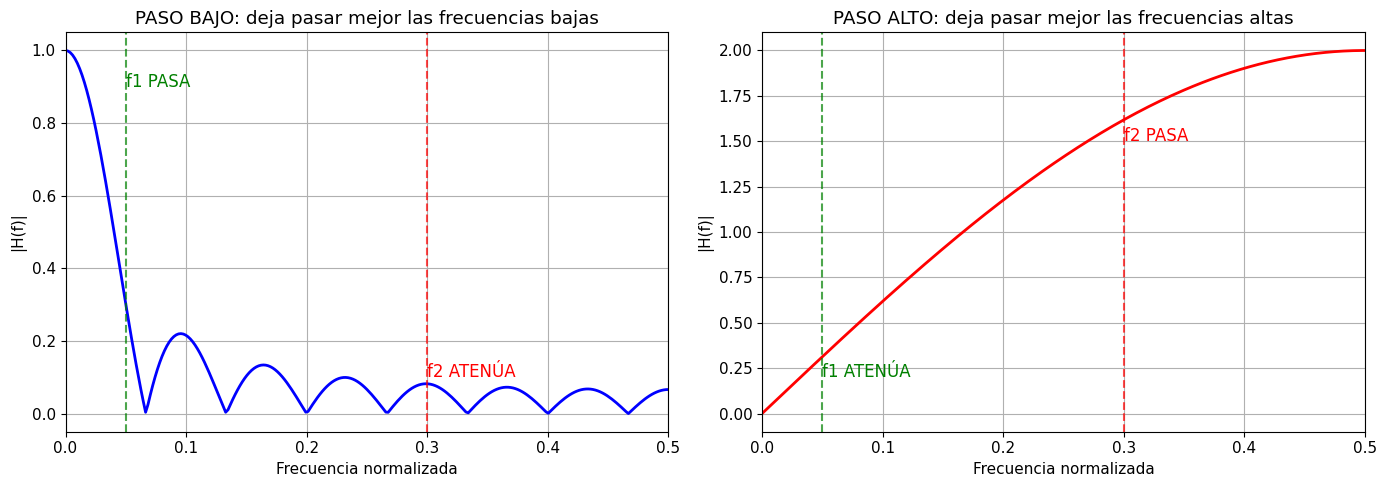

In [25]:
# === VISUALIZACIÓN COMPARATIVA ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Media móvil (paso bajo)
axes[0].plot(f_norm, np.abs(H_media), 'b-', linewidth=2, label='Media móvil')
axes[0].axvline(f1, color='green', linestyle='--', alpha=0.7)
axes[0].axvline(f2, color='red', linestyle='--', alpha=0.7)
axes[0].set_title('PASO BAJO: deja pasar mejor las frecuencias bajas')
axes[0].set_xlabel('Frecuencia normalizada')
axes[0].set_ylabel('|H(f)|')
axes[0].set_xlim([0, 0.5])
axes[0].annotate('f1 PASA', (f1, 0.9), color='green', fontsize=12)
axes[0].annotate('f2 ATENÚA', (f2, 0.1), color='red', fontsize=12)

# Diferenciador (paso alto)
axes[1].plot(f_norm, np.abs(H_diff), 'r-', linewidth=2, label='Diferenciador')
axes[1].axvline(f1, color='green', linestyle='--', alpha=0.7)
axes[1].axvline(f2, color='red', linestyle='--', alpha=0.7)
axes[1].set_title('PASO ALTO: deja pasar mejor las frecuencias altas')
axes[1].set_xlabel('Frecuencia normalizada')
axes[1].set_ylabel('|H(f)|')
axes[1].set_xlim([0, 0.5])
axes[1].annotate('f1 ATENÚA', (f1, 0.2), color='green', fontsize=12)
axes[1].annotate('f2 PASA', (f2, 1.5), color='red', fontsize=12)

plt.tight_layout()
plt.show()

### ✍️ Explicación (OBLIGATORIA)

**Completa la tabla:**

| Filtro          | Tipo de filtro       | ¿Qué frecuencias deja pasar mejor?           | En T6 vimos que...             | En este taller los justificamos con \|H(f)\|                |
|-----------------|------------|----------------------------|--------------------------------|------------------------------------------------|
| Media móvil     | Paso bajo | Frecuencias bajas         | Sobrevive f1 y se atenúa f2           |  \|H(f1)\| > \|H(f2)\|             |
| Diferendicador   | Paso alto | Frecuencias altas         | Sobrevive f2 y se atenúa f1         | \|H(f2)\| > \|H(f1)\|                |

---

### 🔍 Checkpoint del profesor (Parte 1)

- [ ] Respuesta en frecuencia de media móvil calculada
- [ ] Respuesta en frecuencia de diferenciador calculada
- [ ] Conexión con observaciones del Taller 6 establecida

---

## Parte 2: Espectro de señales antes/después del filtrado

### Bloque 3 · Espectro de $x_1$ y de su versión filtrada

Verificamos visualmente que el filtro atenúa ciertas frecuencias.

En este bloque repetimos solo el caso de la media móvil para cerrar la conexión T6↔T8 desde el lado de la frecuencia.

#### 📝 Hipótesis previa

1. ¿Qué pico esperas que permanezca casi intacto después de cada filtrado filtrado? Con media móvil el pico en f1 (frecuencia baja), con diferenciador el pico en f2 (frecuencia alta).
2. ¿Qué componente debería reducirse más en la salida? Con media móvil se reduce f2 y con diferenciador f1.

In [26]:
# === IMPLEMENTACIÓN ===
# TODO: Filtra x1 con media móvil (h_media) y diferenciador (h_diff) a través de la operación de convolución en el dominio del tiempo, para obtener y1_media y y1_diff
y1_media = np.convolve(x1, h_media, mode='same')
y1_diff = np.convolve(x1, h_diff, mode='same')

# TODO: Calcula el espectro de x1, y1_media y y1_diff, obteniendo X1, Y1_media y Y1_diff
X1 = np.fft.fft(x1)
Y1_media = np.fft.fft(y1_media)
Y1_diff = np.fft.fft(y1_diff)

In [27]:
# === VALIDACIÓN ===
assert y1_media is not None, "Calcula la convolución de x1 con h_media"
assert y1_diff is not None, "Calcula la convolución de x1 con h_diff"
assert X1 is not None, "Calcula la FFT de x1"
assert Y1_media is not None, "Calcula la FFT de y1_media"
assert Y1_diff is not None, "Calcula la FFT de y1_diff"
print("✓ Señales calculadas")


✓ Señales calculadas


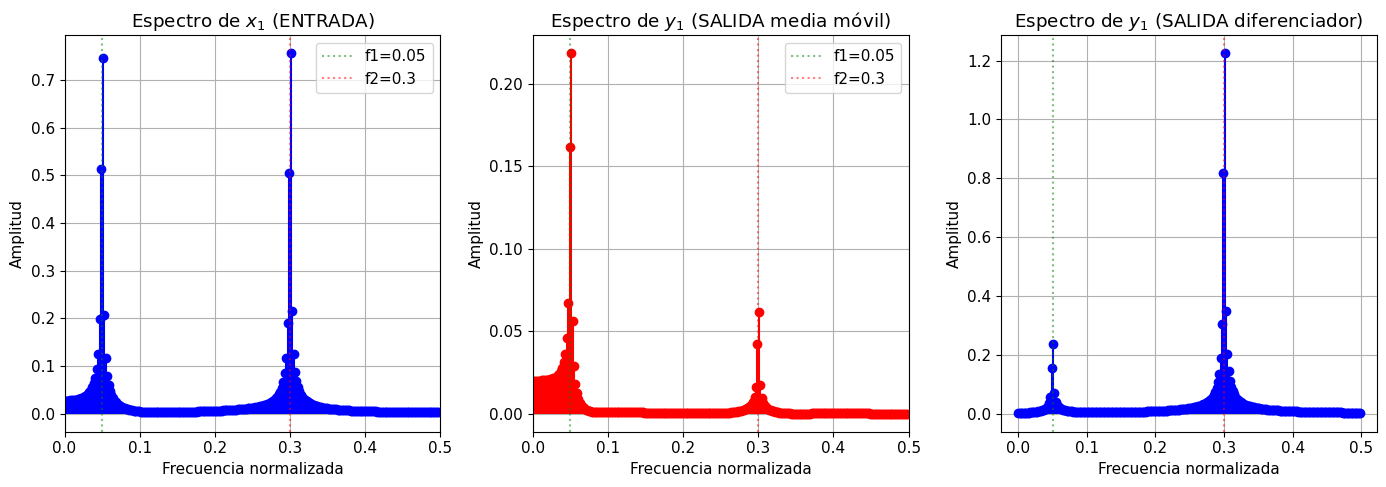

Paso bajo
Amplitud en f1=0.05: entrada=0.747, salida=0.218
Amplitud en f2=0.3: entrada=0.756, salida=0.062

Diferenciador
Amplitud en f1=0.05: entrada=0.747, salida=0.238
Amplitud en f2=0.3: entrada=0.756, salida=1.224


In [28]:
# === VISUALIZACIÓN ===
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Solo frecuencias positivas
mask=np.arange(N//2)

axes[0].stem(f_norm[mask], np.abs(X1[mask]) / N * 2, basefmt=' ', markerfmt='bo', linefmt='b-')
axes[0].axvline(f1, color='green', linestyle=':', alpha=0.5, label=f'f1={f1}')
axes[0].axvline(f2, color='red', linestyle=':', alpha=0.5, label=f'f2={f2}')
axes[0].set_title('Espectro de $x_1$ (ENTRADA)')
axes[0].set_xlabel('Frecuencia normalizada')
axes[0].set_ylabel('Amplitud')
axes[0].set_xlim([0, 0.5])
axes[0].legend()

axes[1].stem(f_norm[mask], np.abs(Y1_media[mask]) / N * 2, basefmt=' ', markerfmt='ro', linefmt='r-')
axes[1].axvline(f1, color='green', linestyle=':', alpha=0.5, label=f'f1={f1}')
axes[1].axvline(f2, color='red', linestyle=':', alpha=0.5, label=f'f2={f2}')
axes[1].set_title('Espectro de $y_1$ (SALIDA media móvil)')
axes[1].set_xlabel('Frecuencia normalizada')
axes[1].set_ylabel('Amplitud')
axes[1].set_xlim([0, 0.5])
axes[1].legend()

axes[2].stem(f_norm[mask], np.abs(Y1_diff[mask]) / N * 2, basefmt=' ', markerfmt='bo', linefmt='b-')
axes[2].axvline(f1, color='green', linestyle=':', alpha=0.5, label=f'f1={f1}')
axes[2].axvline(f2, color='red', linestyle=':', alpha=0.5, label=f'f2={f2}')
axes[2].set_title('Espectro de $y_1$ (SALIDA diferenciador)')
axes[2].set_xlabel('Frecuencia normalizada')
axes[2].set_ylabel('Amplitud')

plt.tight_layout()
plt.show()

# Imprime amplitudes
idx_f1_spec = np.argmin(np.abs(f_norm - f1))
idx_f2_spec = np.argmin(np.abs(f_norm - f2))
print("Paso bajo")
print(f"Amplitud en f1={f1}: entrada={np.abs(X1[idx_f1_spec])/N*2:.3f}, salida={np.abs(Y1_media[idx_f1_spec])/N*2:.3f}")
print(f"Amplitud en f2={f2}: entrada={np.abs(X1[idx_f2_spec])/N*2:.3f}, salida={np.abs(Y1_media[idx_f2_spec])/N*2:.3f}")
print("\nDiferenciador")
print(f"Amplitud en f1={f1}: entrada={np.abs(X1[idx_f1_spec])/N*2:.3f}, salida={np.abs(Y1_diff[idx_f1_spec])/N*2:.3f}")
print(f"Amplitud en f2={f2}: entrada={np.abs(X1[idx_f2_spec])/N*2:.3f}, salida={np.abs(Y1_diff[idx_f2_spec])/N*2:.3f}")

### ✍️ Explicación (OBLIGATORIA)

**¿El espectro de salida confirma lo que viste en el T6?**

*Tu respuesta:*

```
Sí.
En el caso del filtro de media móvil (paso bajo), la amplitud en la frecuencia baja f1 = 0.05 se reduce menos que la de alta frecuencia f2 = 0.3, lo que indica que el filtro atenúa más las componentes de alta frecuencia.
En el caso del diferenciador (paso alto), la amplitud en la frecuencia alta f2 aumenta significativamente, mientras que la de baja frecuencia f1 se mantiene mucho menor, confirmando que este filtro favorece las altas frecuencias.
Los resultados en frecuencia explican perfectamente el comportamiento observado en el dominio del tiempo en el Taller 6.
```

---

## Parte 3: Correlación ↔ Frecuencia (PSD)

### Contexto

La **PSD (Power Spectral Density)** y la **autocorrelación** están relacionadas por la **transformada de Fourier** (Teorema de Wiener-Khinchin):

$$S_{xx}(f) = \mathcal{F}\{R_{xx}[m]\}$$

- Ruido blanco: **Autocorrelación estrecha** ↔ **PSD más distribuida**
- Ruido suavizado: **Autocorrelación ancha** ↔ **PSD concentrada** (bajas frecuencias)

---

### Bloque 4 · PSD de ruido blanco vs ruido suavizado

#### 📝 Hipótesis previa

Antes de calcular nada, anticipa:

1. ¿Qué aspecto esperas para la PSD del ruido blanco ($x_2$)? Espero que sea aproximadamente plana, es decir, con energía distribuida en todas las frecuencias.
2. Si tenemos ruido suavizado ($x_3=x_2$ filtrada con h_media), ¿en qué zona frecuencial debería concentrarse más su energía? Se concentrará en las bajas frecuencias, porque el filtrado elimina las componentes rápidas (altas frecuencias).

#### 🔗 Conexión con Taller 6

> En el T6 viste que:
> - Ruido blanco ($x_2$) → autocorrelación **estrecha** (tipo delta)
> - Ruido suavizado ($x_3$) → autocorrelación **ancha**
>
> Ahora veremos la PSD para **justificar esta diferencia**.

---

In [29]:
# === IMPLEMENTACIÓN ===
# TODO: Calcula la autocorrelación de x2 (ruido blanco), Rxx_blanco
Rxx_blanco = np.correlate(x2, x2, mode='same')

# TODO: Calcula la autocorrelación de x3 (ruido suavizado), Rxx_suave
Rxx_suave = np.correlate(x3, x3, mode='same')

# TODO: Calcula la PSD de Rxx_blanco y Rxx_suave, obteniendo psd_blanco y psd_suave
psd_blanco = np.fft.fft(Rxx_blanco)
psd_suave = np.fft.fft(Rxx_suave)


In [30]:
# === VALIDACIÓN ===
assert psd_blanco is not None, "Calcula la PSD del ruido blanco"
assert psd_suave is not None, "Calcula la PSD del ruido suavizado"
print("✓ PSDs calculadas")

✓ PSDs calculadas


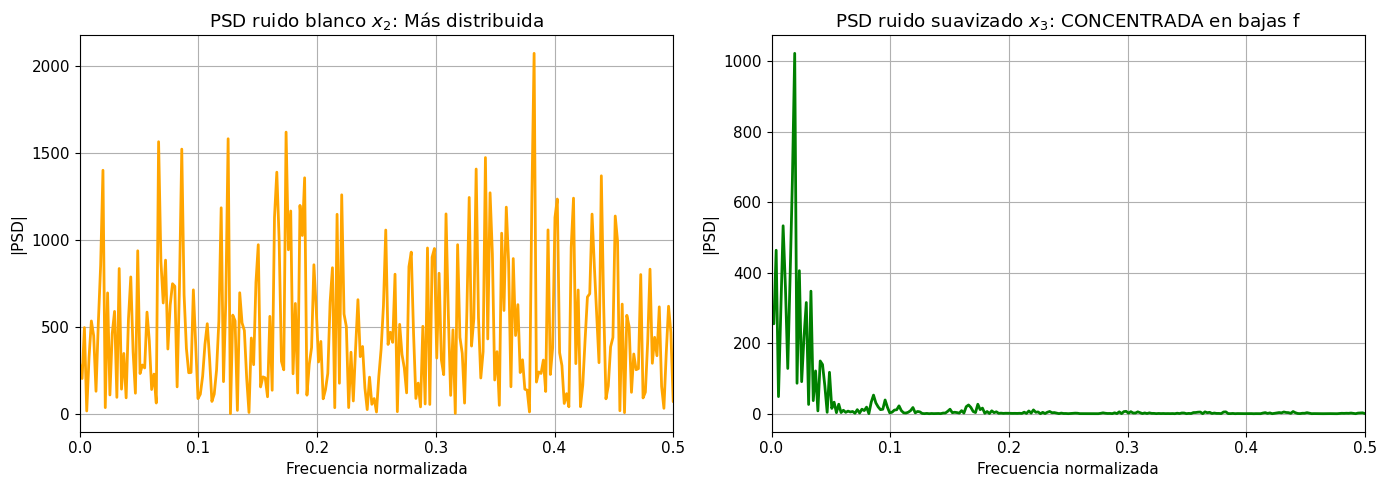

In [31]:
# === VISUALIZACIÓN ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(f_norm, np.abs(psd_blanco), 'orange', linewidth=2)
axes[0].set_title('PSD ruido blanco $x_2$: Más distribuida')
axes[0].set_xlabel('Frecuencia normalizada')
axes[0].set_ylabel('|PSD|')
axes[0].set_xlim([0, 0.5])

axes[1].plot(f_norm, np.abs(psd_suave), 'green', linewidth=2)
axes[1].set_title('PSD ruido suavizado $x_3$: CONCENTRADA en bajas f')
axes[1].set_xlabel('Frecuencia normalizada')
axes[1].set_ylabel('|PSD|')
axes[1].set_xlim([0, 0.5])

plt.tight_layout()
plt.show()

### ✍️ Explicación (OBLIGATORIA)

**Completa la conexión T6↔T8:**

*Tu respuesta:*

```
En el Taller 6 observamos que el ruido blanco tiene una autocorrelación muy estrecha, mientras que el ruido suavizado presenta una autocorrelación más ancha.
Esto corresponde con la PSD:
El ruido blanco tiene una PSD aproximadamente plana, indicando que su energía está distribuida en todas las frecuencias. El ruido suavizado tiene una PSD concentrada en bajas frecuencias, ya que el filtrado elimina las componentes de alta frecuencia.
```

---

### 🔍 Checkpoint del profesor (Parte 3)

- [ ] PSD de ruido blanco es aproximadamente plana
- [ ] PSD de ruido suavizado está concentrada en bajas frecuencias
- [ ] Conexión autocorrelación ↔ PSD establecida

---

### Bloque 4b · Filtrado en frecuencia vs convolución

**Concepto clave:** La propiedad de convolución nos dice que filtrar en tiempo (convolución) es equivalente a multiplicar en frecuencia:

$$y[n] = x[n] * h[n] \quad \Leftrightarrow \quad Y(f) = X(f) \cdot H(f)$$

Esto permite diseñar filtros directamente en el dominio de la frecuencia.

#### 📝 Hipótesis previa

1. ¿Deberían coincidir exactamente ambos métodos salvo errores numéricos? Sí, deben coincidir salvo pequeños errores numéricos.
2. ¿Qué ventaja computacional esperas de filtrar vía FFT cuando la señal o el filtro son largos? Multiplicar en frecuencia es más eficiente para señales largas.

In [34]:
# === DEMOSTRACIÓN: Filtrado en frecuencia ===

# Partimos de la señal x1 (suma de dos tonos) y del filtrado por convolución con h_media que obtuvimos antes en y1_media
# Se hace la convolución por medio de la propiedad de convoluión, multiplicando en frecuencia. Para ello trabajamos con un número $N$ suficientemente grande para que la convolución lineal quepa en el ese valor Nfft.

# TODO: Calculamos el número de bins de la FFT, Nfft, para que la convolución lineal quepa en él, que será la longitud de la señal más la del filtro menos 1.
Nfft = len(x1) + len(h_media) - 1

# TODO: Calculamos la FFT de x1 y h_media con Nfft bins, obteniendo X1 y H_media
X1 = np.fft.fft(x1, Nfft)
H_media = np.fft.fft(h_media, Nfft)

# TODO: Multiplica en frecuencia X1 y H_media, obteniendo Y1_freq
Y1_freq = X1 * H_media

# TODO: Calcula la señal filtrada en el dominio del tiempo, y1_freq_media.
# Para eliminar errores de redondeo, usa np.real para obtener la parte real de la señal una vez calculada la IFFT
y1_freq_media = np.real(np.fft.ifft(Y1_freq))
start = (len(h_media) - 1) // 2
end = start + len(x1)
y1_freq_media = y1_freq_media[start:end]

# TODO: Calculo del Error Cuadrático Medio entre ambos métodos (y1_media y y1_freq_media), mse
mse = np.mean((y1_media - y1_freq_media)**2)

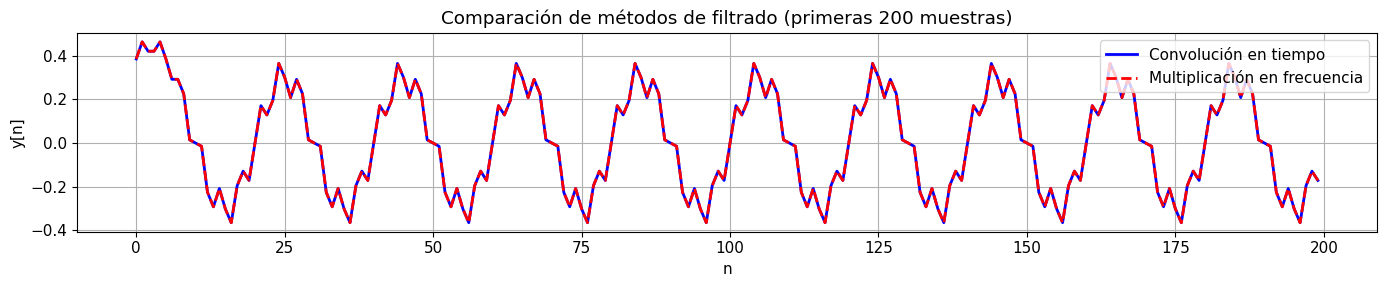

Comprobamos que ambos métodos son equivalentes
Error Cuadrático Medio: 2.11e-32

=== FILTRADO EN FRECUENCIA ===
Ventaja: Para filtros largos, multiplicar en frecuencia es más rápido que convolucionar
Complejidad convolución: O(N·M) = O(512·15) = O(7680)
Complejidad FFT: O(N·log(N)) = O(526·9) = O(4754)


In [35]:
assert np.allclose(y1_media, y1_freq_media, atol=1e-5), (
    "La convolución temporal y el filtrado en frecuencia deben coincidir"
)

# Comparación
plt.figure(figsize=(14, 3))
plt.plot(n[:200], y1_media[:200], 'b-', linewidth=2, label='Convolución en tiempo')
plt.plot(n[:200], y1_freq_media[:200], 'r--', linewidth=2, label='Multiplicación en frecuencia')
plt.title('Comparación de métodos de filtrado (primeras 200 muestras)')
plt.legend()
plt.xlabel('n')
plt.ylabel('y[n]')
plt.tight_layout()
plt.show()

print("Comprobamos que ambos métodos son equivalentes")
print(f"Error Cuadrático Medio: {mse:.2e}")
print()
print("=== FILTRADO EN FRECUENCIA ===")
print("Ventaja: Para filtros largos, multiplicar en frecuencia es más rápido que convolucionar")
print(f"Complejidad convolución: O(N·M) = O({N}·{M}) = O({N*M})")
print(f"Complejidad FFT: O(N·log(N)) = O({Nfft}·{int(np.log2(Nfft))}) = O({int(Nfft*np.log2(Nfft))})")

### ✍️ Explicación (OBLIGATORIA)

**¿Qué ventajas proporciona la propiedad de convolución?:**

*Tu respuesta:*

```
Permite realizar el filtrado en el dominio de la frecuencia mediante una multiplicación, en lugar de una convolución en el tiempo.
Esto reduce la complejidad computacional, especialmente para señales largas, pasando de O(N.M) a O(NlogN), lo que hace el procesamiento mucho más eficiente.
```

---

### Bloque 4c · Filtrado de interferencias

En este caso se filtrará una señal de voz a la que se le superpone una interferencia de un fuerte tono en una frecuencia concreta. En nuestro caso en F_i=1000 Hz

Para eliminar esta interferencia, se usará un sistema que filtre alrededor del tono interferente (filtro de banda eliminada o notch filter), todo ello en frecuencia, recuperando la señal resultante en el dominio del tiempo. Este filtro en frecuencia es un vector de todo 1's, excepto en las frecuencias a eliminar, donde valdrá cero.

In [36]:
# Obtención de la señal de voz y superposición de tono interferente.

# Descargar el archivo de voz
url_voz = '../helpers/VozCorta.wav'

# Lee el archivo de audio desde el fichero local
with open(url_voz, 'rb') as f:
    audio_data = f.read()

# Abre un archivo temporal para guardar el contenido del audio
with open('temp_audio_file', 'wb') as audio_file:
    audio_file.write(audio_data)

# Carga el archivo de audio temporal con librosa
xvoz, Fs = librosa.load('temp_audio_file', sr=None)  # `sr=None` mantiene la tasa de muestreo original

# Superposición de tono interferente en la frecuencia Fint
Fint = 1200            # Frecuencia de la señal interferente para probar

# Para conseguir una longitud de la señal que contenga un número exacto de periodos de la interferencia, se añaden ceros al final de la señal de voz. De esta forma, la señal resultante tiene una longitud que es múltiplo de la frecuencia de la interferencia, evitando el fenómeno de smearing que se verá en el siguiente taller.
L = len(xvoz)
xvoz = np.concatenate([
    xvoz,
    np.zeros(int(Fint * np.ceil(L / Fint)) - L)
])

print(f'Frecuencia de muestreo de la señal de voz: {Fs} Hz')
print(f'Frecuencia de la interferencia: {Fint} Hz')
n = np.arange(len(xvoz))
xvoz_interf = xvoz + np.cos(2 * np.pi * Fint / Fs * n)

Frecuencia de muestreo de la señal de voz: 8000 Hz
Frecuencia de la interferencia: 1200 Hz


In [37]:
# Número de bins de la FFT igual a la longitud de la señal xvoz_interf, Nfft_voz_interf
Nfft_voz_interf=len(xvoz_interf)

# TODO: Calcula la FFT de la señal con interferencia, xvoz_interf, para obtener X_voz_interf
X_voz_interf = np.fft.fft(xvoz_interf)

# TODO: Calcula los dos bins (las deltas de la señal coseno) de la frecuencia de la interferencia, redondeados al entero más bajo: k_interf1, k_interf2
# Haz el cálculo de forma determinista, basado en la frecuencia de muestreo y el número de bins de la FFT y la frecuencia de la interferencia. No uses np.argmax para buscar los máximos de la señal X_voz_interf
k_interf1 = int(Fint / Fs * Nfft_voz_interf)
k_interf2 = Nfft_voz_interf - k_interf1

margen = 2

# TODO: Elimina la interferencia en el dominio de la frecuencia, igualando a cero los bins de la interferencia en frecuencia X_voz_interf.
# En lugar de igualar a cero sólo los bins de la interferencia, hazlo en estos y en 2 bins (valor almacenado en una variable denominada margen) a la izquierda y a la derecha.
# El resultado se guarda en Y_voz_filt
Y_voz_filt = X_voz_interf.copy()
Y_voz_filt[k_interf1-margen:k_interf1+margen] = 0
Y_voz_filt[k_interf2-margen:k_interf2+margen] = 0

# TODO: Calcula la señal filtrada, Y_voz_filt, en el dominio del tiempo, yvoz_filt
# Para eliminar efectos de redondeo, usa la función np.real sobre la señal obtenida en el dominio del tiempo con la IFFT
yvoz_filt = np.real(np.fft.ifft(Y_voz_filt))

Filtro aplicado correctamente


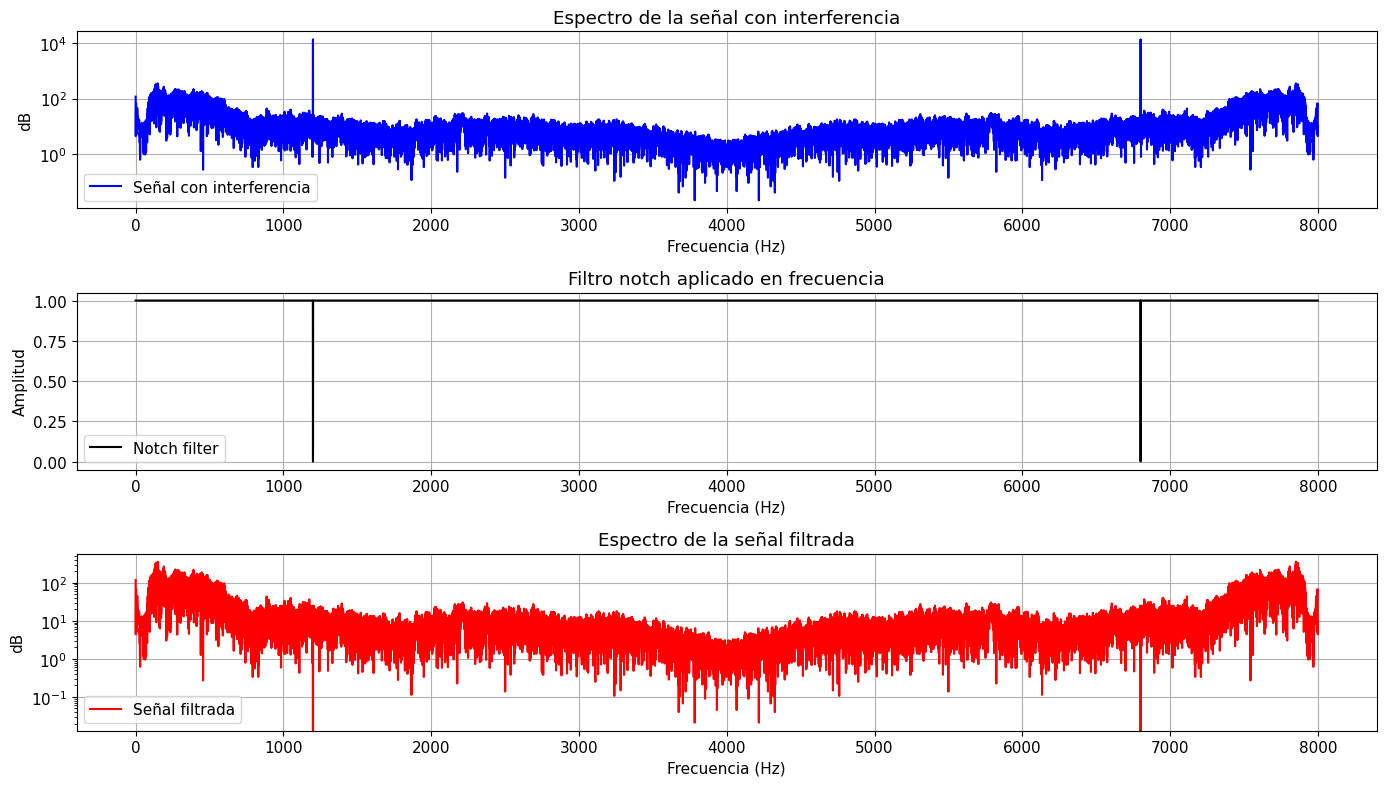

Señal con la interferencia


Señal filtrada


In [38]:
# === VALIDACIÓN ===
k_interf1_estimado = np.argmax(np.abs(X_voz_interf))
k_interf2_estimado = Nfft_voz_interf - k_interf1_estimado
assert k_interf1 == k_interf1_estimado, "El bin de la interferencia no se ha eliminado correctamente"
assert k_interf2 == k_interf2_estimado, "El bin de la interferencia no se ha eliminado correctamente"
assert np.allclose(Y_voz_filt[k_interf1-margen:k_interf1+margen], 0, atol=1e-10), "El bin de la interferencia no se ha eliminado correctamente"
assert np.allclose(Y_voz_filt[k_interf2-margen:k_interf2+margen], 0, atol=1e-10), "El bin de la interferencia no se ha eliminado correctamente"

print("Filtro aplicado correctamente")
# Muestra el espectrograma de la señal con interferencia y la señal filtrada
frecs = np.linspace(0, Fs - Fs/Nfft_voz_interf, Nfft_voz_interf)

notch_filter = np.ones(Nfft_voz_interf)
notch_filter[k_interf1-margen:k_interf1+margen] = 0
notch_filter[k_interf2-margen:k_interf2+margen] = 0

# === VISUALIZACIÓN ===
fig, axes = plt.subplots(3, 1, figsize=(14, 8))

# Espectro de la señal con interferencia
axes[0].semilogy(frecs, np.abs(X_voz_interf), 'b', label='Señal con interferencia')
axes[0].set_title('Espectro de la señal con interferencia')
axes[0].set_xlabel('Frecuencia (Hz)')
axes[0].set_ylabel('dB')
axes[0].legend()

# Muestra el filtro notch aplicado en frecuencia
axes[1].plot(frecs, notch_filter , 'k', label='Notch filter')
axes[1].set_xlabel('Frecuencia (Hz)')
axes[1].set_ylabel('Amplitud')
axes[1].set_title('Filtro notch aplicado en frecuencia')
axes[1].legend()

# Espectro de la señal filtrada
axes[2].semilogy(frecs, np.abs(Y_voz_filt), 'r', label='Señal filtrada')
axes[2].set_title('Espectro de la señal filtrada')
axes[2].set_xlabel('Frecuencia (Hz)')
axes[2].set_ylabel('dB')
axes[2].legend()

plt.tight_layout()
plt.show()

# Reproducción de la señal de voz con la interferencia
print('Señal con la interferencia')
ipd.display(ipd.Audio(data=xvoz_interf,rate=Fs))

# Reproducción de la señal filtrada
print('Señal filtrada')
ipd.display(ipd.Audio(data=yvoz_filt,rate=Fs))


---

## Parte 4: STFT y espectrograma

### Contexto

Hasta aquí hemos justificado las observaciones del Taller 6 usando las **mismas señales y sistemas**. A partir de ahora abrimos una pregunta nueva: ¿qué ocurre cuando la frecuencia **cambia con el tiempo**? Para estudiar esa no estacionariedad necesitamos señales nuevas.

Para señales **no estacionarias** (que cambian en el tiempo), usamos la **STFT**:

$$\text{STFT}\{x[n]\}(m, k) = \sum_{n} x[n] \cdot w[n-m] \cdot e^{-j2\pi kn/N}$$

**Trade-off tiempo-frecuencia:**
- Ventana larga → buena resolución frecuencia, mala tiempo
- Ventana corta → buena resolución tiempo, mala frecuencia

---

### Bloque 5 · Señal chirp y espectrograma

#### 📝 Hipótesis previa

1. Si la frecuencia instantánea aumenta con el tiempo, ¿qué forma esperas ver en el espectrograma? Una línea diagonal ascendente, porque la frecuencia aumenta progresivamente con el tiempo.
2. ¿Qué crees que mostrará mejor un espectrograma que una FFT única? El espectrograma muestra cómo evoluciona la frecuencia en el tiempo, mientras que una FFT única solo da las frecuencias presentes sin información temporal.

In [39]:
# Señal chirp: frecuencia que aumenta linealmente
N_chirp = 1000
n_chirp = np.arange(N_chirp)

f_start, f_end = 0.02, 0.40  # frecuencias normalizadas
T_chirp = N_chirp

# Fase instantánea
phase = 2 * np.pi * (f_start * n_chirp + (f_end - f_start) * n_chirp**2 / (2 * T_chirp))
x_chirp = np.sin(phase)

print(f"✓ Chirp generado: f varía de {f_start} a {f_end}")

✓ Chirp generado: f varía de 0.02 a 0.4


In [40]:
# === IMPLEMENTACIÓN ===
# Calcula el espectrograma de la señal chirp con una ventana de 128 muestras
muestras_ventana = 128  # Número de muestras de la ventana
muestras_solapamiento = 96  # Número de muestras de solapamiento    
f_spec, t_spec, Sxx = signal.spectrogram(x_chirp, nperseg=muestras_ventana, noverlap=muestras_solapamiento)

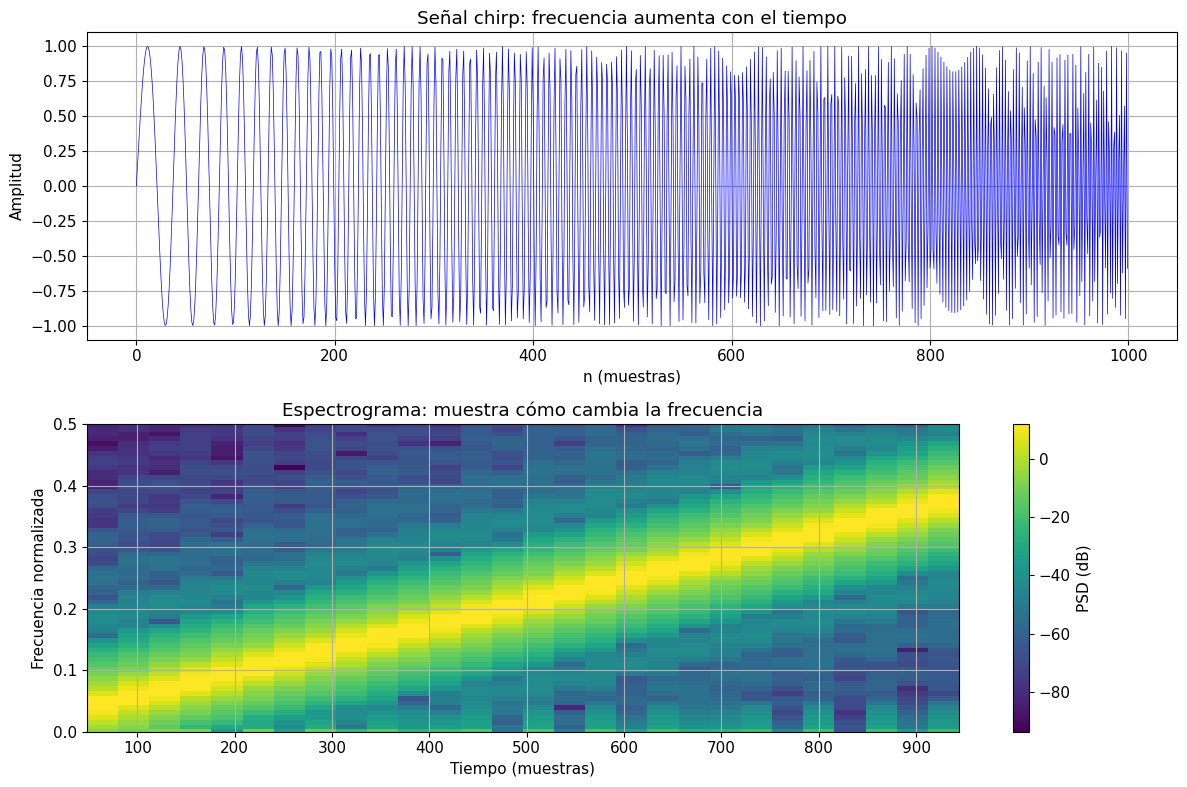

In [41]:
# === VISUALIZACIÓN ===
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Señal temporal
axes[0].plot(n_chirp, x_chirp, 'b-', linewidth=0.5)
axes[0].set_title('Señal chirp: frecuencia aumenta con el tiempo')
axes[0].set_xlabel('n (muestras)')
axes[0].set_ylabel('Amplitud')

# Espectrograma
pcm = axes[1].pcolormesh(t_spec, f_spec, 10*np.log10(Sxx + 1e-10), 
                         shading='auto', cmap='viridis')
axes[1].set_title('Espectrograma: muestra cómo cambia la frecuencia')
axes[1].set_xlabel('Tiempo (muestras)')
axes[1].set_ylabel('Frecuencia normalizada')
axes[1].set_ylim([0, 0.5])
plt.colorbar(pcm, ax=axes[1], label='PSD (dB)')

plt.tight_layout()
plt.show()

---

### Bloque 5b · Señal multi-tono por segmentos

**Contexto:** A diferencia del chirp que tiene una transición continua de frecuencia, una señal real puede cambiar de frecuencia abruptamente (p. ej., cambios de nota en música, cambios de modo en comunicaciones).

Este bloque genera una señal que cambia de frecuencia en saltos discretos y observa cómo el espectrograma muestra transiciones **afiladas** en lugar de suaves.

#### 📝 Hipótesis previa

1. ¿Esperas ver trazas horizontales o diagonales?
2. ¿En qué instantes deberían apreciarse con claridad los cambios de frecuencia?

**Parámetros de la señal:**
- $f_1 = 10$ Hz para $0 \leq t < 5$ s
- $f_2 = 25$ Hz para $5 \leq t < 10$ s
- $f_3 = 50$ Hz para $10 \leq t < 15$ s
- $f_4 = 100$ Hz para $15 \leq t < 20$ s
- $F_s = 400$ Hz

In [42]:
# === IMPLEMENTACIÓN ===
# Genera la señal multi-tono por segmentos
# Parámetros físicos:
Fs = 400        # Frecuencia de muestreo (Hz)
T_total = 20    # Duración total (s)
N_multi = int(T_total * Fs)  # Número de muestras
t = np.arange(N_multi) / Fs   # Vector temporal en segundos

# Frecuencias de cada segmento (en Hz)
f1_hz, f2_hz, f3_hz, f4_hz = 10, 25, 50, 100

# Crea la señal por segmentos
x_multi = np.zeros(N_multi)

# Rellena x_multi con los 4 segmentos sinusoidales
# Segmento 1: cos(2π·10·t) para 0 ≤ t < 5s
# Segmento 2: cos(2π·25·t) para 5 ≤ t < 10s
# Segmento 3: cos(2π·50·t) para 10 ≤ t < 15s
# Segmento 4: cos(2π·100·t) para 15 ≤ t < 20s
mask1 = (t >= 0) & (t < 5)
mask2 = (t >= 5) & (t < 10)
mask3 = (t >= 10) & (t < 15)
mask4 = (t >= 15) & (t < 20)

x_multi[mask1] = np.cos(2 * np.pi * f1_hz * t[mask1])
x_multi[mask2] = np.cos(2 * np.pi * f2_hz * t[mask2])
x_multi[mask3] = np.cos(2 * np.pi * f3_hz * t[mask3])
x_multi[mask4] = np.cos(2 * np.pi * f4_hz * t[mask4])

# === VALIDACIÓN ===
assert len(x_multi) == N_multi, "La señal debe tener la longitud correcta"
assert not np.all(x_multi == 0), "Tienes que llenar x_multi con los segmentos"

print(f"✓ Señal multi-tono generada: {N_multi} muestras, {T_total} segundos")
print(f"  Frecuencias: {f1_hz} Hz → {f2_hz} Hz → {f3_hz} Hz → {f4_hz} Hz")

✓ Señal multi-tono generada: 8000 muestras, 20 segundos
  Frecuencias: 10 Hz → 25 Hz → 50 Hz → 100 Hz


In [43]:
# === CÁLCULO DEL ESPECTROGRAMA ===
# Calculo del espectrograma de x_multi
# Usa signal.spectrogram(x_multi, fs=Fs, nperseg=128)
muestras_ventana = 128  # Número de muestras de la ventana
muestras_solapamiento = 96  # Número de muestras de solapamiento    
f_multi_spec, t_multi_spec, Sxx_multi = signal.spectrogram(x_multi, fs=Fs, nperseg=muestras_ventana, noverlap=muestras_solapamiento)

# === VALIDACIÓN ===
assert Sxx_multi is not None, "Calcula el espectrograma de la señal multi-tono"
print("✓ Espectrograma de señal multi-tono calculado")

✓ Espectrograma de señal multi-tono calculado


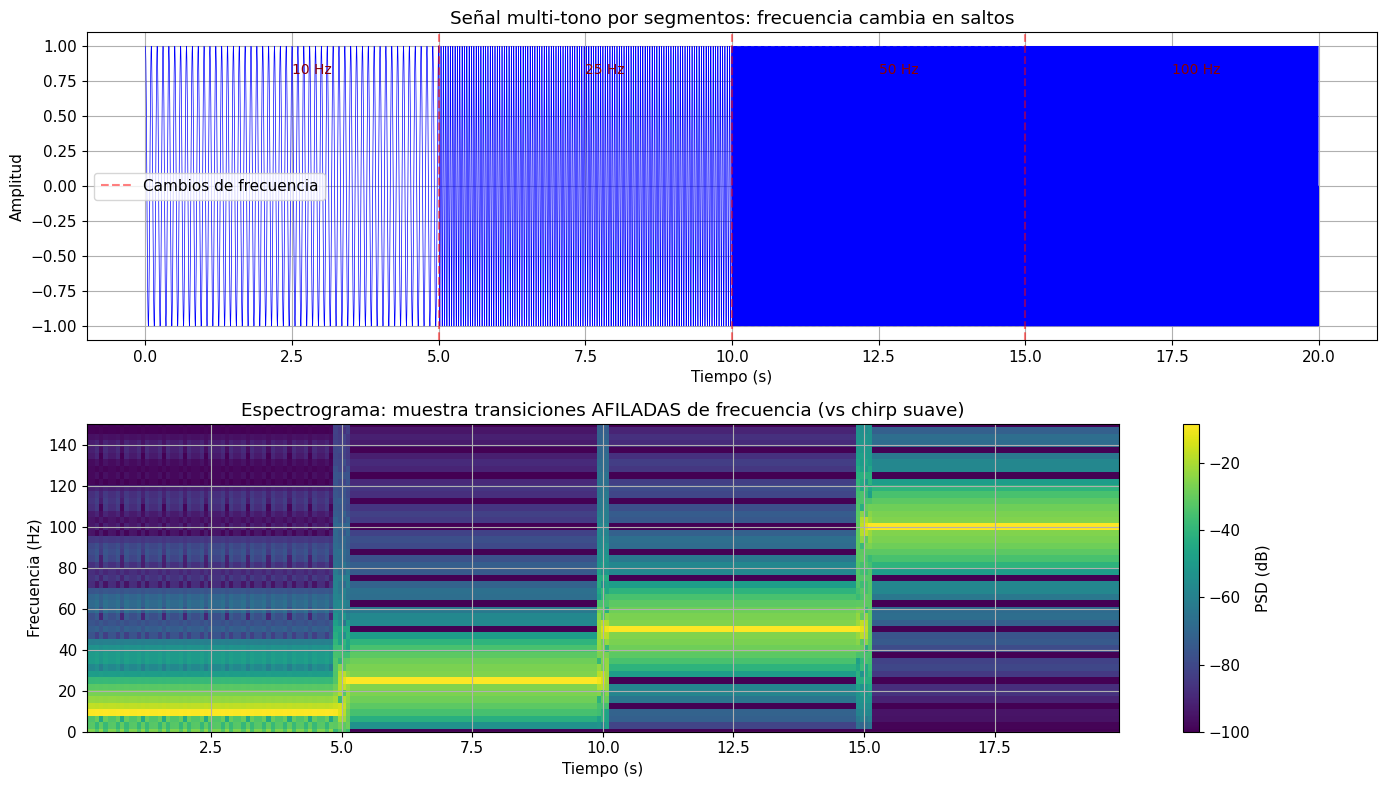

In [44]:
# === VISUALIZACIÓN ===
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Señal temporal
axes[0].plot(t, x_multi, 'b-', linewidth=0.5)
axes[0].axvline(5, color='red', linestyle='--', alpha=0.5, label='Cambios de frecuencia')
axes[0].axvline(10, color='red', linestyle='--', alpha=0.5)
axes[0].axvline(15, color='red', linestyle='--', alpha=0.5)
axes[0].annotate('10 Hz', xy=(2.5, 0.8), fontsize=10, color='darkred')
axes[0].annotate('25 Hz', xy=(7.5, 0.8), fontsize=10, color='darkred')
axes[0].annotate('50 Hz', xy=(12.5, 0.8), fontsize=10, color='darkred')
axes[0].annotate('100 Hz', xy=(17.5, 0.8), fontsize=10, color='darkred')
axes[0].set_title('Señal multi-tono por segmentos: frecuencia cambia en saltos')
axes[0].set_xlabel('Tiempo (s)')
axes[0].set_ylabel('Amplitud')
axes[0].legend()

# Espectrograma
pcm = axes[1].pcolormesh(t_multi_spec, f_multi_spec, 10*np.log10(Sxx_multi + 1e-10), 
                         shading='auto', cmap='viridis')
axes[1].set_title('Espectrograma: muestra transiciones AFILADAS de frecuencia (vs chirp suave)')
axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylabel('Frecuencia (Hz)')
axes[1].set_ylim([0, 150])
plt.colorbar(pcm, ax=axes[1], label='PSD (dB)')

plt.tight_layout()
plt.show()

### ✍️ Explicación (OBLIGATORIA)

**Comparación de los espectrogramas de la señal Chirp vs Multi-tono**

*Tu respuesta:*

```
En el espectrograma de la señal multi-tono se observan líneas horizontales bien definidas, lo que indica que la frecuencia es constante en cada intervalo de tiempo.
Además, se aprecian transiciones bruscas y verticales en los instantes t = 5 s, 10 s y 15 s, que corresponden a los cambios de frecuencia entre los distintos segmentos.
En contraste, el espectrograma de la señal chirp mostraría una línea diagonal continua, ya que la frecuencia cambia de forma progresiva con el tiempo, sin saltos abruptos.
```

---
### Bloque 5c · Trade-off tiempo-frecuencia

#### 📝 Hipótesis previa

Antes de comparar ventanas, predice:

1. ¿Qué tamaño de ventana localizará mejor un cambio brusco en el tiempo? Una ventana corta, porque tiene mejor resolución temporal.
2. ¿Qué tamaño de ventana separará mejor dos frecuencias cercanas? Una ventana larga, porque tiene mejor resolución en frecuencia.

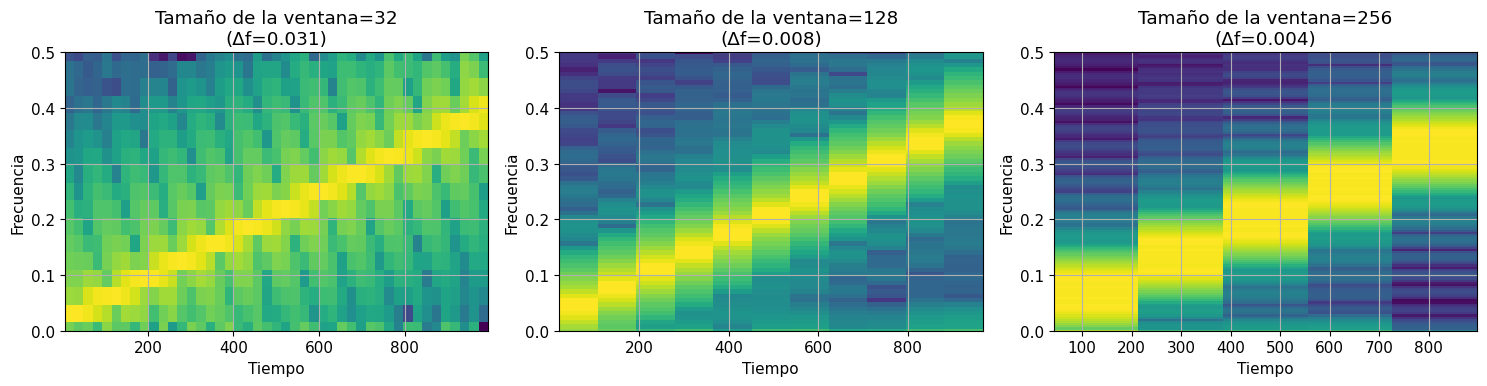

In [45]:
# Comparación de diferentes tamaños de ventana
muestras_ventanas = [32, 128, 256]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, nperseg in zip(axes, muestras_ventanas):
    f, t, S = signal.spectrogram(x_chirp, nperseg=nperseg, noverlap=nperseg//3)
    ax.pcolormesh(t, f, 10*np.log10(S + 1e-10), shading='auto', cmap='viridis')
    ax.set_title(f'Tamaño de la ventana={nperseg}\n(Δf={1/nperseg:.3f})')
    ax.set_xlabel('Tiempo')
    ax.set_ylabel('Frecuencia')
    ax.set_ylim([0, 0.5])

plt.tight_layout()
plt.show()

### ✍️ Explicación (OBLIGATORIA)

**¿Qué tamaño de ventana me muestra mejor la evolución temporal de la frecuencia?:**

*Tu respuesta:*

```
La ventana pequeña (32) muestra mejor la evolución temporal, ya que permite seguir con mayor precisión los cambios en el tiempo. 
En la imagen se observa que la traza es más difusa en frecuencia, pero sigue bien la progresión temporal del chirp.
```

**¿Qué tamaño de ventana me concentra mejor las frecuencias dentro de esta?:**

*Tu respuesta:*

```
La ventana grande (256) concentra mejor las frecuencias. La línea es más fina y definida en frecuencia, hay menos dispersión vertical. Mejor resolución frecuencial.
```

**De las respuestas anteriores, ¿hay alguna solución perfecta que proporcione una buena resolución temporal y frecuencial al mismo tiempo?:**

*Tu respuesta:*

```
No, no existe una solución perfecta.
Ventana 32 -> buena en tiempo, mala en frecuencia
Ventana 256 -> buena en frecuencia, mala en tiempo
Ventana 128 -> compromiso intermedio
```

---

### 🔍 Checkpoint del profesor (Parada STFT)

- [ ] Diferencia entre chirp y multi-tono explicada
- [ ] Trade-off tiempo-frecuencia razonado con ejemplos concretos
- [ ] Efecto de tamaño comparado con criterio

---

## Preguntas de control

### P1. ¿Qué significa que un filtro tenga $|H(f)|$ alto en bajas frecuencias y bajo en altas?

*Tu respuesta:*

```
Significa que el filtro deja pasar las componentes de baja frecuencia y atenúa las de alta frecuencia.
Es un filtro paso bajo, que suaviza la señal eliminando variaciones rápidas.
```

---

### P2. ¿Cómo se relaciona la autocorrelación con la PSD?

*Tu respuesta:*

```
La PSD es la transformada de Fourier de la autocorrelación, según el teorema de Wiener-Khinchin.
Esto implica que:
autocorrelación estrecha -> PSD distribuida
autocorrelación ancha -> PSD concentrada
```

---

### P3. ¿Por qué el ruido blanco tiene PSD plana?

*Tu respuesta:*

```
Porque el ruido blanco contiene todas las frecuencias con la misma potencia. Su autocorrelación es tipo delta, lo que implica que su transformada es constante en todas las frecuencias.
```

---

### P4. Explica el trade-off tiempo-frecuencia en la STFT.

*Tu respuesta:*

```
Existe un compromiso entre resolución temporal y frecuencial:
. ventana corta -> buena resolución temporal, mala en frecuencia
. ventana larga -> buena resolución en frecuencia, mala temporal
```

---

### P5. ¿Por qué en la parte de STFT ya no basta con reutilizar solo las señales estacionarias del Taller 6?

*Tu respuesta:*

```
Porque las señales estacionarias no cambian en el tiempo, por lo que una FFT única es suficiente para analizarlas.
En cambio, la STFT se usa para señales no estacionarias, donde el contenido frecuencial varía con el tiempo, y necesitamos analizar cómo evoluciona la frecuencia.
```

---

## ✅ Checklist final

- [ ] Run All sin errores
- [ ] Respuesta en frecuencia de ambos filtros calculada
- [ ] Conexión con observaciones del Taller 6 establecida
- [ ] Teorema de Parseval verificado
- [ ] PSD de ruido blanco vs suavizado comparada
- [ ] Relación autocorrelación↔PSD entendida
- [ ] Filtrado en frecuencia vs convolución demostrado
- [ ] Espectrograma de chirp calculado
- [ ] Señal multi-tono generada y espectrograma calculado
- [ ] Trade-off tiempo-frecuencia explorado
- [ ] Preguntas de control respondidas con tus propias palabras
- [ ] Todas las explicaciones completadas